In [1]:
import os
from pathlib import Path
import pandas as pd
from typing import List, Dict
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import lru_cache


from rdkit import Chem
from rdkit.Chem import Descriptors

In [2]:
# __file__ = str(Path(".").absolute() / "interaction_scores.ipynb")
# __file__
NB_DIR = Path(".").absolute() / "interaction_scores.ipynb"
NB_DIR

PosixPath('/home/fatemeh/thesis/kinodata-3D-affinity-prediction/prob/probing_notebooks/interaction_scores.ipynb')

In [3]:
print(os.getcwd())
# _ROOT = Path(os.environ.get("HOME_PROJ_DIR", Path(__file__).resolve().parents[2]))
_ROOT = Path(os.environ.get("HOME_PROJ_DIR", NB_DIR.resolve().parents[2]))
os.chdir(_ROOT)
print(os.getcwd())

/home/fatemeh/thesis/kinodata-3D-affinity-prediction/prob/probing_notebooks
/home/fatemeh/thesis/kinodata-3D-affinity-prediction


In [4]:
interactions_dir = _ROOT / "data" / "plip_kinodata3d" / "processed"
interaction_names = ["halogen_bonds", "hydrogen_bonds", "hydrophobic_interactions", "pi_stacking", "salt_bridges"]

mapping = pd.read_csv(_ROOT / "data" / "ident_to_activity_id.csv")
mapping.rename(columns={"activities.activity_id": "activity_id"}, inplace=True)

# halogen_bonds_df = pd.read_csv(interactions_dir / "halogen_bonds.csv")
hydrogen_bonds_df = pd.read_csv(interactions_dir / "hydrogen_bonds.csv")
# hydrophobic_interactions_df = pd.read_csv(interactions_dir / "hydrophobic_interactions.csv")
# pi_stacking_df = pd.read_csv(interactions_dir / "pi_stacking.csv")
# salt_bridges_df = pd.read_csv(interactions_dir / "salt_bridges.csv")

# # interactions = [pd.read_csv(interactions_dir / f) for f in interaction_files]
# interactions_dfs = [halogen_bonds_df,
#                 hydrogen_bonds_df,
#                 hydrophobic_interactions_df,
#                 pi_stacking_df,
#                 salt_bridges_df]

### Plotting functions

In [33]:

def plot_dist_with_log(
    df: pd.DataFrame,
    col: str,
    bins: int = 100,
    kde: bool = False,
    show_ecdf: bool = False,
):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

    # --- Linear scale ---
    sns.histplot(
        data=df,
        x=col,
        bins=bins,
        kde=kde,
        stat="count",
        edgecolor="black",
        alpha=0.85,
        ax=axes[0],
    )
    axes[0].set_title(f"{col} distribution")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    if show_ecdf:
        ax_ecdf = axes[0].twinx()
        sns.ecdfplot(
            data=df,
            x=col,
            ax=ax_ecdf,
            color="C1",
            linewidth=2,
        )
        ax_ecdf.set_ylabel("ECDF")
        ax_ecdf.set_ylim(0, 1)

    # --- Log-scaled y-axis ---
    sns.histplot(
        data=df,
        x=col,
        bins=bins,
        kde=kde,
        stat="count",
        # log_scale=(False, True),
        element="bars",      # force rectangles
        fill=True,
        edgecolor="black",
        alpha=0.85,
        ax=axes[1],
    )
    axes[1].set_yscale("symlog", linthresh=20) 
    axes[1].set_title(f"{col} distribution (log-scaled counts)")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Count (log scale)")

    if show_ecdf:
        ax_ecdf = axes[1].twinx()
        sns.ecdfplot(
            data=df,
            x=col,
            ax=ax_ecdf,
            color="C1",
            linewidth=2,
        )
        ax_ecdf.set_ylabel("ECDF")
        ax_ecdf.set_ylim(0, 1)

    # for ax in axes:
    #     sns.despine(ax=ax)

    plt.tight_layout()
    return axes

### Continuous Intercation Score

The final score will be calculated as:
$$
\displaystyle\sum_{\text{residues}}{\text{residue attribution score} × \frac{\displaystyle\sum_{\text{bonds}}{\text{bond score}}}{\text{total number of bonds the ligand CAN form}}}
$$

### Discrete Interaction Score

This would be just the total number of interactions, factored by $MW^{-1}$

$MW$ is to account for the total number of bonds a molecule can form. Because the bigger the molecule, the more the number of bonds it can have

# H-bonds
What PLIP does:
- Donor–acceptor distance $d_{DA}$ is $≤ 4.1 Å$ `(HBOND_DIST_MAX = 4.1)`
- Donor angle $∠(D−H⋯A)$ is $≥ 100°$ `(HBOND_DON_ANGLE_MIN = 100)`
- If the same groups already form a salt bridge, PLIP removes the overlapping hydrogen bond(s) (to avoid double-reporting)
- A donor is restricted to one H-bond; if multiple acceptors are possible, PLIP keeps the one whose $∠(D−H⋯A)$ is closest to $180°$. Acceptors can still participate in multiple bonds (bifurcated cases).

Let's define:

$\colorbox{yellow}{This is the old version and it's wrong!}$

**Q**: a quality score that does not change too abruptly near the geometric thresholds, using a smooth logistic formulation to do this and to keep it in $[0,1]$:
$$
s_\theta = \sigma\!\left(\frac{d_{\max} - d}{\lambda_d}\right) \text{, and } s_d = \sigma\!\left(\frac{\theta - \theta_{\min}}{\lambda_\theta}\right)
$$
$$ 
Q = s_\theta \cdot s_d
$$

where the logistic (sigmoid) function is defined as:
$$ \sigma(x) = \frac{1}{1 + e^{-x}} $$

**Parameters:**

- $ d $: donor–acceptor distance (Å)  
- $ \theta $: donor–acceptor angle (degrees)  
- $ d_{\max} $: maximum distance cutoff (e.g. 4.1 Å in PLIP)  
- $ \theta_{\min} $: minimum angle cutoff (e.g. 100° in PLIP)  
- $ \lambda_d $: controls how fast the distance contribution ramps  
  (here **0.2–0.4 Å**)  
- $ \lambda_\theta $: controls angular softness  
  (here **5–15°**)  

The resulting score $Q \in (0,1)$, with higher values corresponding to shorter and more linear hydrogen bonds.

$\colorbox{yellow}{The new version:}$

The relationship between the strength of the bond and angle and distance is so:
The stronger the bond, when:
- The more the angle is close to 180
- The less the distance


**So, we can say:**
$$
Q \propto \frac{\cos(∠(D−H⋯A))}{d_{DA}}  
$$

In [9]:
hydrogen_bonds_df.head()

,RESNR,RESTYPE,RESCHAIN,RESNR_LIG,RESTYPE_LIG,RESCHAIN_LIG,SIDECHAIN,DIST_H-A,DIST_D-A,DON_ANGLE,PROTISDON,DONORIDX,DONORTYPE,ACCEPTORIDX,ACCEPTORTYPE,LIGCOO,PROTCOO,activity_id
0,48,LEU,A,1,UNL,Z,False,1.79,2.69,151.89,False,1455,Npl,789,O2,"(-1.477, 18.513, 44.666)","(-3.405, 19.71, 46.118)",23227035
1,48,LEU,A,1,UNL,Z,False,1.92,2.90,162.57,True,784,Nam,1450,Nar,"(-0.942, 20.548, 43.637)","(-2.308, 22.328, 45.472)",23227035
2,52,SER,A,1,UNL,Z,False,2.03,2.96,151.87,True,845,Nam,1456,O2,"(-3.751, 12.62, 44.282)","(-4.813, 14.725, 42.494)",23227035
3,45,THR,A,1,UNL,Z,True,1.67,2.53,146.08,True,735,O3,1434,O2,"(1.909, 21.593, 40.698)","(3.132, 23.547, 41.736)",2111945
4,48,MET,A,1,UNL,Z,False,2.07,2.78,127.30,False,1432,Npl,782,O2,"(-1.082, 18.606, 45.341)","(-3.599, 19.474, 46.129)",2111945


- The column to use as $d$ is `DIST_D-A` $\rightarrow$ do I wanna incorporate `DIST_H-A` too? How? A weighted sum maybe?
- The column to use as $\theta$ is `DON_ANGLE`

count    322499.000000
mean          0.752999
std           0.227277
min           0.173648
25%           0.605711
50%           0.834271
75%           0.941412
max           1.000000
Name: cos_angle, dtype: float64


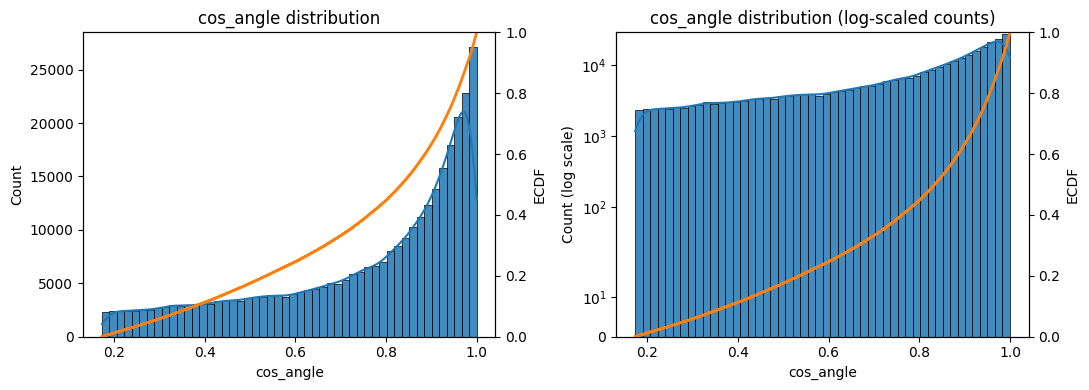

In [34]:
hydrogen_bonds_df["cos_angle"] = -np.cos(
    np.deg2rad(hydrogen_bonds_df["DON_ANGLE"])
)
# hydrogen_bonds_df["cos_angle"].hist(bins=50)
# plt.xlabel("cosine of Donor Angle")
# plt.ylabel("Frequency")
# plt.title("Distribution of Cosine of Donor Angle in Hydrogen Bonds")
plot_dist_with_log(hydrogen_bonds_df, "cos_angle", bins=50, kde=True, show_ecdf=True)
print(hydrogen_bonds_df["cos_angle"].describe())

In [17]:
# Defaults
D_MAX = 4.1        # Å
THETA_MIN = 100.0  # degrees
lam_theta_min = 90.0  # degrees
lam_theta_max = 150.0  # degrees
lam_d_min = 2.4  # Å
lam_d_max = 4.4  # Å

#### Plot to choose the $\lambda$ values:

In [7]:
def sigmoid(x: float) -> float:
    return 1.0 / (1.0 + np.exp(-x))

def s_d(d: float, lam_d: float, d_max: float = D_MAX) -> float:
    return sigmoid((d_max - d) / lam_d)

def s_theta(theta: float, lam_theta: float, theta_min: float = THETA_MIN) -> float:
    return sigmoid((theta - theta_min) / lam_theta)

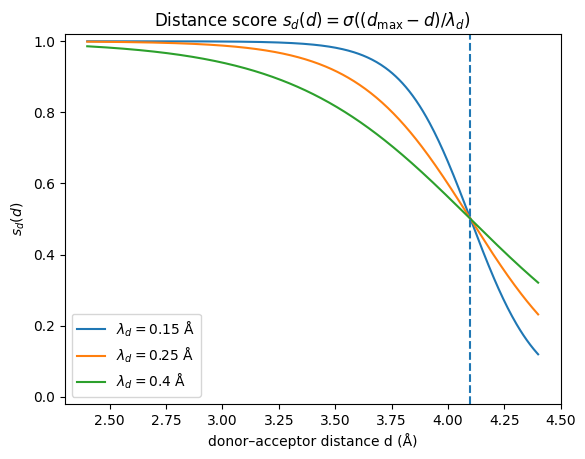

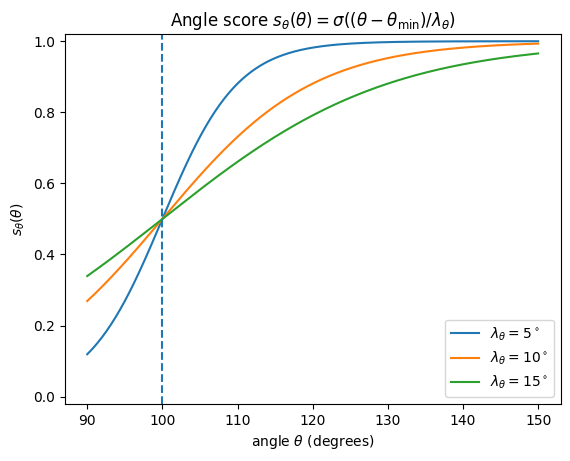

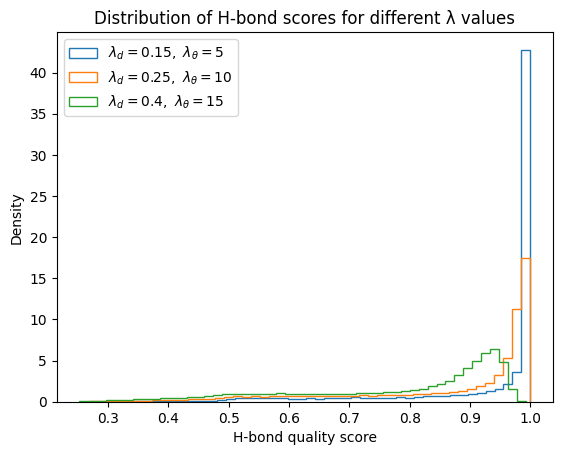

In [ ]:
# ranges to plot
d_vals = np.linspace(lam_d_min, lam_d_max, 400)
theta_vals = np.linspace(lam_theta_min, lam_theta_max, 400)

# try a few lambdas
lam_ds = [0.15, 0.25, 0.40, 0.5]        # Å
lam_thetas = [5, 10, 15]           # degrees

# ---- plot distance curves ----
plt.figure()
for lam in lam_ds:
    plt.plot(d_vals, s_d(d_vals, lam), label=fr'$\lambda_d={lam}$ Å')
plt.axvline(D_MAX, linestyle='--')  # cutoff marker
plt.xlabel('donor–acceptor distance d (Å)')
plt.ylabel(r'$s_d(d)$')
plt.title(r'Distance score $s_d(d)=\sigma((d_{\max}-d)/\lambda_d)$')
plt.legend()
plt.ylim(-0.02, 1.02)
plt.show()

# ---- plot angle curves ----
plt.figure()
for lam in lam_thetas:
    plt.plot(theta_vals, s_theta(theta_vals, lam), label=fr'$\lambda_\theta={lam}^\circ$')
plt.axvline(THETA_MIN, linestyle='--')  # cutoff marker
plt.xlabel(r'angle $\theta$ (degrees)')
plt.ylabel(r'$s_\theta(\theta)$')
plt.title(r'Angle score $s_\theta(\theta)=\sigma((\theta-\theta_{\min})/\lambda_\theta)$')
plt.legend()
plt.ylim(-0.02, 1.02)
plt.show()


# ---- plot histogram of H-bond scores ----
plt.figure()

for lam_d, lam_theta in zip(lam_ds, lam_thetas):
    scores = (
        s_d(hydrogen_bonds_df["DIST_D-A"], lam_d)
        * s_theta(hydrogen_bonds_df["DON_ANGLE"], lam_theta)
    )
    plt.hist(
        scores,
        bins=50,
        density=True,
        histtype="step",
        label=fr"$\lambda_d={lam_d},\ \lambda_\theta={lam_theta}$"
    )

plt.xlabel("H-bond quality score")
plt.ylabel("Density")
plt.title("Distribution of H-bond scores for different λ values")
plt.legend()
plt.show()

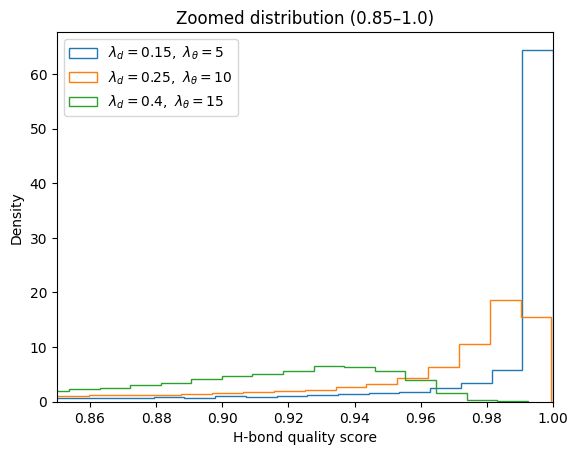

In [33]:
lam_pairs = [(0.15, 5), (0.25, 10), (0.4, 15)]

plt.figure()
for lam_d, lam_theta in lam_pairs:
    scores = s_d(hydrogen_bonds_df["DIST_D-A"], lam_d) * s_theta(hydrogen_bonds_df["DON_ANGLE"], lam_theta)
    plt.hist(scores, bins=80, density=True, histtype="step",
             label=fr"$\lambda_d={lam_d},\ \lambda_\theta={lam_theta}$")

plt.xlim(0.85, 1.0)  # zoom
plt.xlabel("H-bond quality score")
plt.ylabel("Density")
plt.title("Zoomed distribution (0.85–1.0)")
plt.legend()
plt.show()

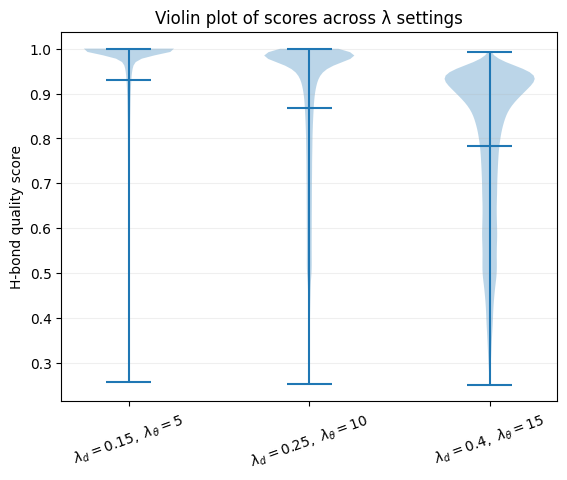

In [34]:
score_list = []
labels = []

for lam_d, lam_theta in lam_pairs:
    scores = s_d(hydrogen_bonds_df["DIST_D-A"], lam_d) * s_theta(hydrogen_bonds_df["DON_ANGLE"], lam_theta)
    score_list.append(np.asarray(scores))
    labels.append(fr"$\lambda_d={lam_d},\ \lambda_\theta={lam_theta}$")

plt.figure()
plt.violinplot(score_list, showmeans=True, showextrema=True)
plt.xticks(np.arange(1, len(labels)+1), labels, rotation=20)
plt.ylabel("H-bond quality score")
plt.title("Violin plot of scores across λ settings")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

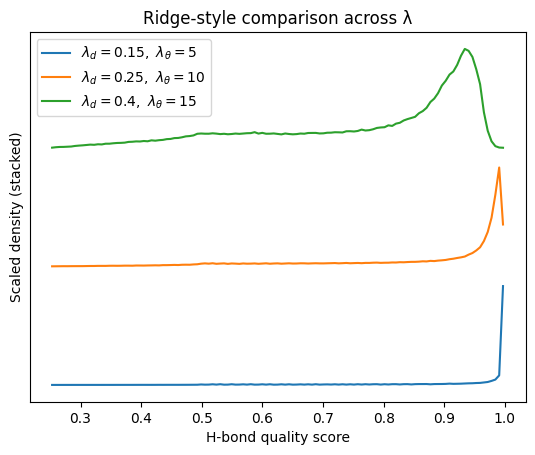

In [35]:
bins = np.linspace(0.25, 1.0, 120)

plt.figure()
offset = 0.0
for lam_d, lam_theta in lam_pairs:
    scores = np.asarray(s_d(hydrogen_bonds_df["DIST_D-A"], lam_d) * s_theta(hydrogen_bonds_df["DON_ANGLE"], lam_theta))
    hist, edges = np.histogram(scores, bins=bins, density=True)
    centers = 0.5 * (edges[1:] + edges[:-1])

    # normalize each curve so they have similar height
    hist = hist / (hist.max() + 1e-9)

    plt.plot(centers, hist + offset, label=fr"$\lambda_d={lam_d},\ \lambda_\theta={lam_theta}$")
    offset += 1.2

plt.xlabel("H-bond quality score")
plt.ylabel("Scaled density (stacked)")
plt.title("Ridge-style comparison across λ")
plt.legend()
plt.yticks([])
plt.show()

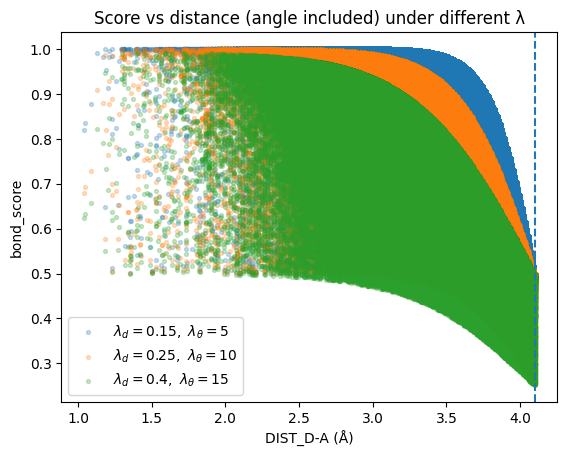

In [36]:
lam_pairs = [(0.15, 5), (0.25, 10), (0.4, 15)]

plt.figure()
for lam_d, lam_theta in lam_pairs:
    scores = s_d(hydrogen_bonds_df["DIST_D-A"], lam_d) * s_theta(hydrogen_bonds_df["DON_ANGLE"], lam_theta)
    plt.scatter(hydrogen_bonds_df["DIST_D-A"], scores, s=8, alpha=0.25,
                label=fr"$\lambda_d={lam_d},\ \lambda_\theta={lam_theta}$")

plt.axvline(4.1, linestyle="--")
plt.xlabel("DIST_D-A (Å)")
plt.ylabel("bond_score")
plt.title("Score vs distance (angle included) under different λ")
plt.legend()
plt.show()

### Making a new df that has the scores, and join that to the bond df:

In [7]:
lam_d = 0.4  # Å
lam_theta = 15  # degrees

Mode: 2.99


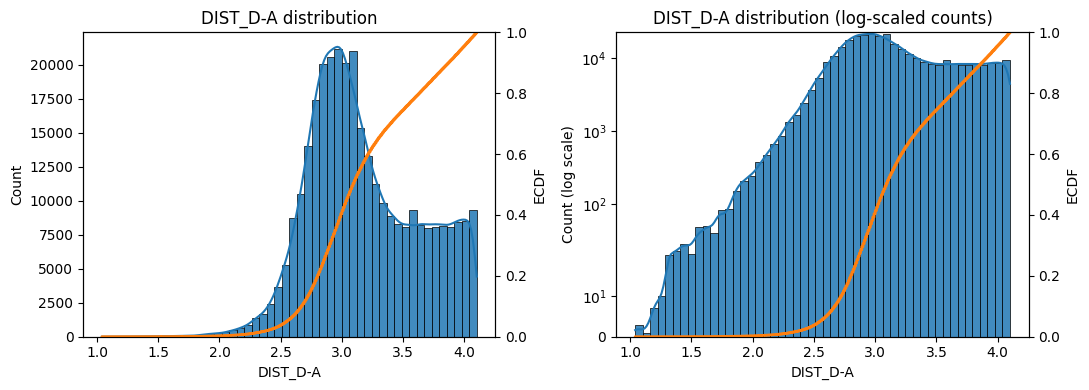

In [36]:
# hydrogen_bonds_df["DIST_D-A"].hist(bins=50)
# plt.xlabel("Donor-Acceptor Distance (Å)")
# plt.ylabel("Frequency")
# plt.title("Distribution of Donor-Acceptor Distances in Hydrogen Bonds")
# print(hydrogen_bonds_df["DIST_D-A"].describe())
plot_dist_with_log(hydrogen_bonds_df, "DIST_D-A", bins=50, kde=True, show_ecdf=True)
print(f"Mode: {hydrogen_bonds_df['DIST_D-A'].mode()[0]}")

$\colorbox{yellow}{Thoughts on this: }$
Maybe it's better to penalize both tails, and assign best score to a ideal middle distance.

This can be modeled with a Gaussian, peaked around an ideal distance.

$$
s_d(d) = \exp(- \frac{(d-d^*)^2}{2\sigma^2})
$$

So the score would be 1 at $d=d^*$

The $\sigma$ would control the speed of the penalization. To pick $\sigma$, <br>
We choose:
- ideal donor–acceptor distance: $ d^* = 2.9\ \text{Å} $
- desired score at $ d = 4.0\ \text{Å} $: $ s_d(4.0) = 0.1 $

Substituting into the equation:

$$
0.1 = \exp\!\left(-\frac{(4.0 - 2.9)^2}{2\sigma^2}\right)
$$

Taking the natural logarithm:

$$
\ln(0.1) = -\frac{1.1^2}{2\sigma^2}
$$

Solving for \( \sigma \):

$$
\sigma^2 = \frac{1.1^2}{-2\ln(0.1)}
$$

$$
\sigma = \frac{1.1}{\sqrt{-2\ln(0.1)}} \approx 0.51\ \text{Å}
$$

Thus, choosing $ \sigma \approx 0.5\ \text{Å} $ yields a chemically reasonable distance score where
donor–acceptor distances near the cutoff ($\sim 4.0\ \text{Å}$) are assigned low but nonzero quality.


count    322499.000000
mean          0.709237
std           0.314231
min           0.001293
25%           0.455031
50%           0.860096
75%           0.972698
max           1.000000
Name: s_d_gauss, dtype: float64


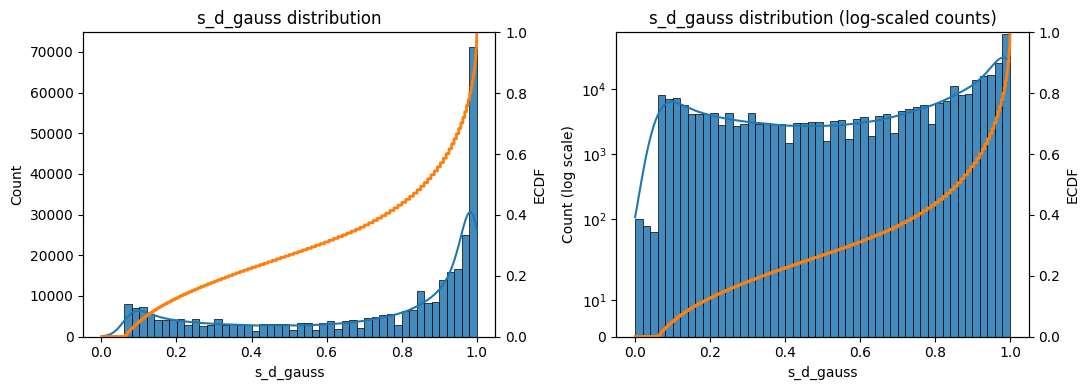

In [37]:
# d_star = hydrogen_bonds_df["DIST_D-A"].mode()[0]
d_star = 2.9
sigma = 0.51

d = hydrogen_bonds_df["DIST_D-A"].to_numpy(dtype=float)

hydrogen_bonds_df["s_d_gauss"] = np.exp(-((d - d_star) ** 2) / (2 * sigma ** 2))

plot_dist_with_log(hydrogen_bonds_df, "s_d_gauss", bins=50, kde=True, show_ecdf=True)
print(hydrogen_bonds_df["s_d_gauss"].describe())


<Axes: >

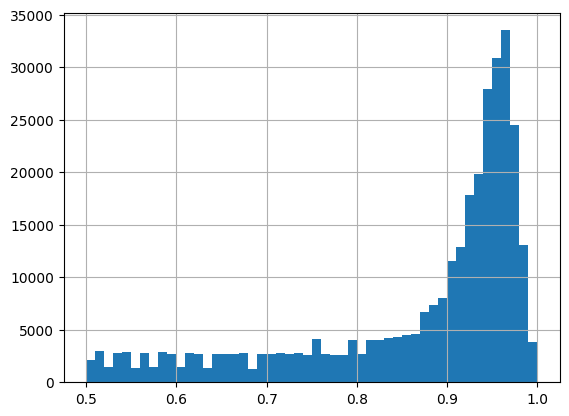

In [22]:
s_d_vals = s_d(hydrogen_bonds_df["DIST_D-A"], lam_d)
s_d_vals.hist(bins=50)

In [ ]:
s_d_clipped = np.clip(hydrogen_bonds_df["DIST_D-A"]-D_MAX, 0.0, 1.0)

No Gaussian: count    322499.000000
mean          0.244523
std           0.086196
min           0.043000
25%           0.183000
50%           0.262000
75%           0.314000
max           0.749000
Name: bond_score, dtype: float64
With Gaussian: count    322499.000000
mean          1.689457
std           2.390476
min           0.174000
25%           0.858000
50%           1.000000
75%           1.447000
max         236.601000
Name: bond_score_gauss, dtype: float64


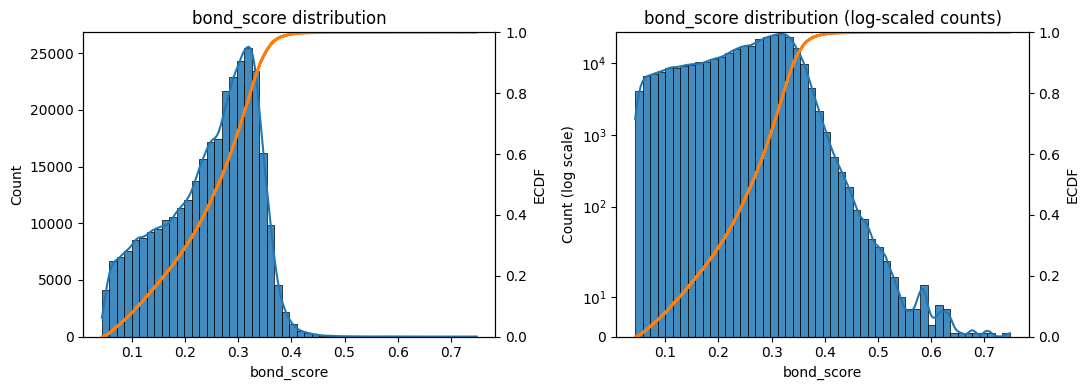

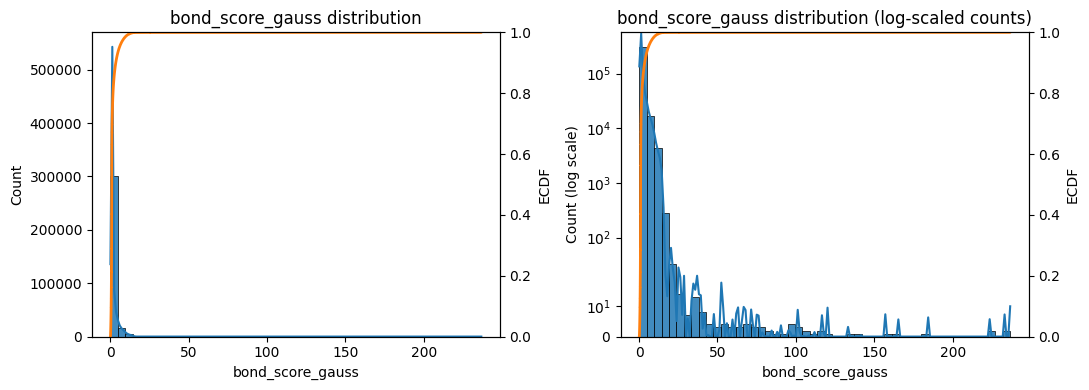

In [40]:
# Old score
# hydrogen_bonds_df["bond_score"] = (round(s_d(d = hydrogen_bonds_df["DIST_D-A"], lam_d = lam_d) *
#                                   s_theta(theta = hydrogen_bonds_df["DON_ANGLE"], lam_theta=lam_theta), 3))

# New score

hydrogen_bonds_df["bond_score"] = (round(hydrogen_bonds_df["cos_angle"] / hydrogen_bonds_df["DIST_D-A"], 3))
hydrogen_bonds_df["bond_score_gauss"] = (round(hydrogen_bonds_df["cos_angle"] / hydrogen_bonds_df["s_d_gauss"], 3))
# hydrogen_bonds_df[["DIST_D-A", "DON_ANGLE", "bond_score"]].head(10)
plot_dist_with_log(hydrogen_bonds_df, "bond_score", bins=50, kde=True, show_ecdf=True)
print(f"No Gaussian: {hydrogen_bonds_df['bond_score'].describe()}")


plot_dist_with_log(hydrogen_bonds_df, "bond_score_gauss", bins=50, kde=True, show_ecdf=True)
print(f"With Gaussian: {hydrogen_bonds_df['bond_score_gauss'].describe()}")

In [9]:
print(len(hydrogen_bonds_df))
hydrogen_bonds_df.head()

322499


,RESNR,RESTYPE,RESCHAIN,RESNR_LIG,RESTYPE_LIG,RESCHAIN_LIG,SIDECHAIN,DIST_H-A,DIST_D-A,DON_ANGLE,PROTISDON,DONORIDX,DONORTYPE,ACCEPTORIDX,ACCEPTORTYPE,LIGCOO,PROTCOO,activity_id,bond_score
0,48,LEU,A,1,UNL,Z,False,1.79,2.69,151.89,False,1455,Npl,789,O2,"(-1.477, 18.513, 44.666)","(-3.405, 19.71, 46.118)",23227035,0.942
1,48,LEU,A,1,UNL,Z,False,1.92,2.90,162.57,True,784,Nam,1450,Nar,"(-0.942, 20.548, 43.637)","(-2.308, 22.328, 45.472)",23227035,0.938
2,52,SER,A,1,UNL,Z,False,2.03,2.96,151.87,True,845,Nam,1456,O2,"(-3.751, 12.62, 44.282)","(-4.813, 14.725, 42.494)",23227035,0.916
3,45,THR,A,1,UNL,Z,True,1.67,2.53,146.08,True,735,O3,1434,O2,"(1.909, 21.593, 40.698)","(3.132, 23.547, 41.736)",2111945,0.937
4,48,MET,A,1,UNL,Z,False,2.07,2.78,127.30,False,1432,Npl,782,O2,"(-1.082, 18.606, 45.341)","(-3.599, 19.474, 46.129)",2111945,0.830


Sum over residues:

### Calculate MW

Since in the reference df the smiles of each ident exists, we can just use that instead of using kinodatadocked dataset

In [10]:
print(len(mapping))
mapping.head()

119522


,ident_processed,smiles_processed,y_processed,ident,compound_structures.canonical_smiles,activities.standard_value,activity_id,similar.klifs_structure_id
0,0,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,5.148742,0,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,5.148742,32335,5326
1,17,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1CCC...,6.000000,17,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1CCC...,6.000000,40693,5326
2,20,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,5.565431,20,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,5.565431,41979,5326
3,44,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1C[C...,6.568636,44,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1C[C...,6.568636,51886,5326
4,1221,CC(C)(C)n1cc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,5.640165,1221,CC(C)(C)n1cc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,5.640165,443639,5326


In [41]:
@lru_cache(maxsize=200_000)     # to not calculate MW for same SMILES multiple times
def mw_from_smiles(smiles: str) -> float:
    if not isinstance(smiles, str) or not smiles:
        return float("nan")
    mol = Chem.MolFromSmiles(smiles)
    return Descriptors.MolWt(mol) if mol is not None else float("nan")


mapping["mw"] = mapping["smiles_processed"].map(mw_from_smiles)


In [14]:
mapping.head()

,ident_processed,smiles_processed,y_processed,ident,compound_structures.canonical_smiles,activities.standard_value,activity_id,similar.klifs_structure_id,mw
0,0,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,5.148742,0,Nc1ncnc2c1c(-c1cccc(Oc3ccccc3)c1)cn2C1CCCC1,5.148742,32335,5326,370.456
1,17,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1CCC...,6.000000,17,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1CCC...,6.000000,40693,5326,386.455
2,20,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,5.565431,20,c1ccc(Oc2ccc(Nc3ncnc4ccccc34)cc2)cc1,5.565431,41979,5326,313.360
3,44,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1C[C...,6.568636,44,Nc1ncnc2c1c(-c1ccc(Oc3ccccc3)cc1)cn2[C@@H]1C[C...,6.568636,51886,5326,402.454
4,1221,CC(C)(C)n1cc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,5.640165,1221,CC(C)(C)n1cc(-c2ccc(Oc3ccccc3)cc2)c2c(N)ncnc21,5.640165,443639,5326,358.445


Normalize

In [13]:
low, high = mapping["mw"].quantile([0.01, 0.99])
print(f"1st percentile: {low}, 99th percentile: {high}")

1st percentile: 239.28641000000002, 99th percentile: 662.82132


Add Empirical Cumulative Density Function (ECDF) to see for example “90% of molecules have MW ≤ X”

array([<Axes: title={'center': 'mw distribution'}, xlabel='mw', ylabel='Count'>,
       <Axes: title={'center': 'mw distribution (log-scaled counts)'}, xlabel='mw', ylabel='Count (log scale)'>],
      dtype=object)

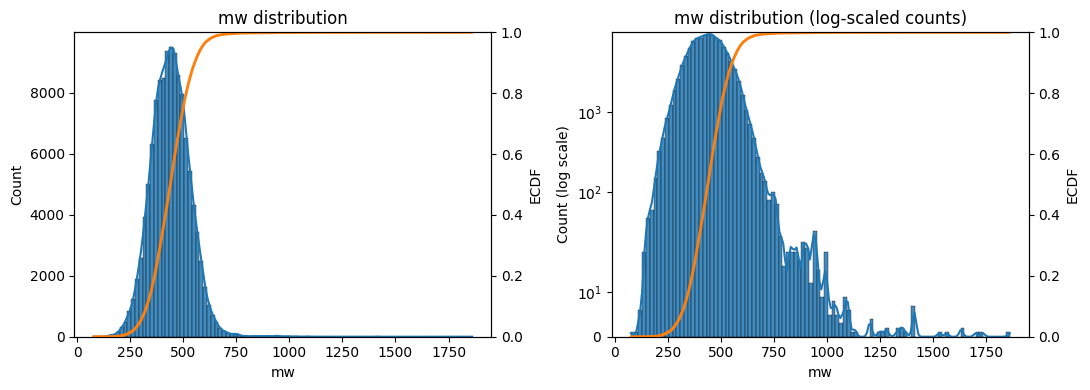

In [119]:
plot_dist_with_log(mapping, col="mw", kde=True, show_ecdf=True)

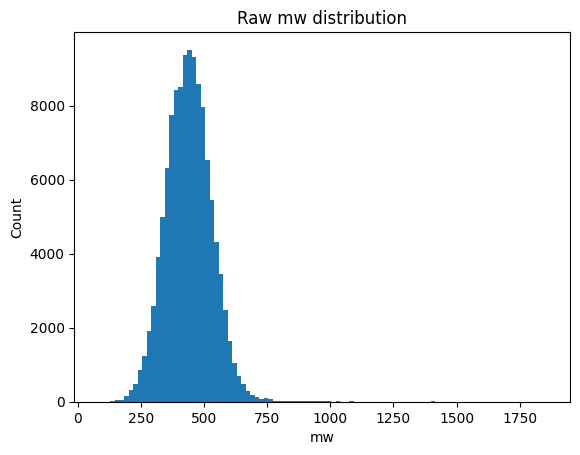

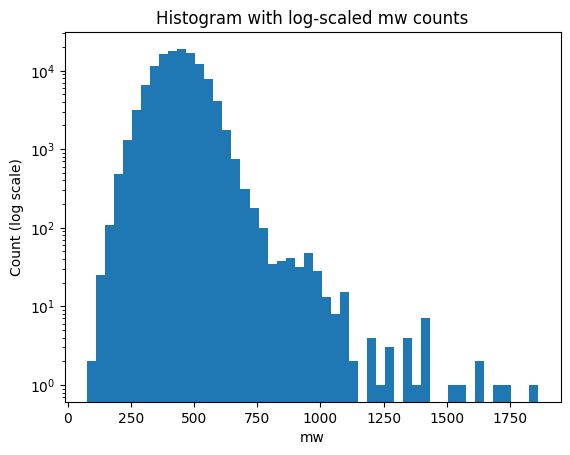

In [15]:
def plot_dist(df, col: str = "mw", bins: int = 100):
    plt.figure()
    plt.hist(df[col], bins=bins)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Raw {col} distribution")
    plt.show()

def plot_dist_log(df, col: str = "mw", bins: int = 50):
    plt.figure()
    plt.hist(df[col], bins=bins)
    plt.yscale("log")
    plt.xlabel(f"{col}")
    plt.ylabel("Count (log scale)")
    plt.title(f"Histogram with log-scaled {col} counts")
    plt.show()

plot_dist(mapping, "mw")
plot_dist_log(mapping, "mw")

Need a clip then

count    119522.000000
mean        440.325440
std          91.328874
min          76.124000
25%         378.404000
50%         438.532000
75%         498.930500
max        1000.000000
Name: mw_filtered, dtype: float64
count    119522.000000
mean        440.439277
std          92.278931
min          76.124000
25%         378.404000
50%         438.532000
75%         498.930500
max        1861.731000
Name: mw, dtype: float64


array([<Axes: title={'center': 'mw_filtered distribution'}, xlabel='mw_filtered', ylabel='Count'>,
       <Axes: title={'center': 'mw_filtered distribution (log-scaled counts)'}, xlabel='mw_filtered', ylabel='Count (log scale)'>],
      dtype=object)

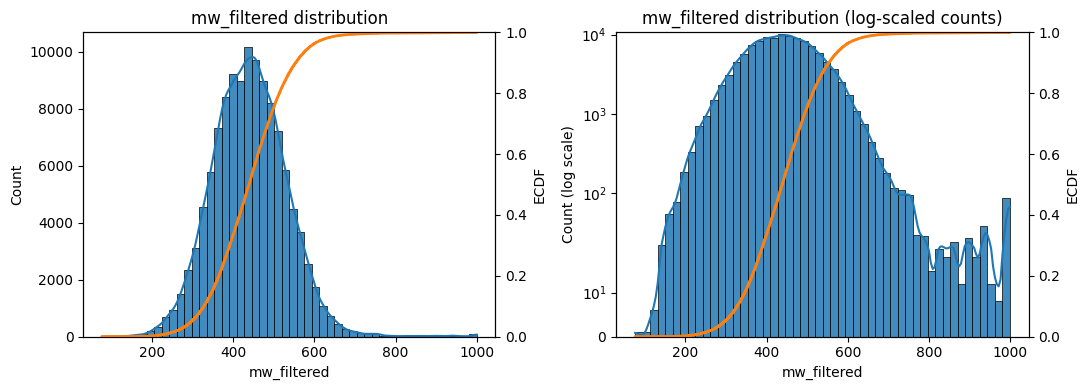

In [43]:
# Filtering outliers based on the diagram:
# mapping["mw_filtered"] = mapping["mw"].where((mapping["mw"] <= 1000.0))   # this replaces values >1000 with NaN
mapping["mw_filtered"] = mapping["mw"].clip(upper=1000.0)
print(mapping["mw_filtered"].describe())
print(mapping["mw"].describe())
plot_dist_with_log(mapping, "mw_filtered", bins=50, kde=True, show_ecdf=True)

Scale first then inverse count    119522.000000
mean          0.002377
std           0.000547
min           0.001000
25%           0.002004
50%           0.002280
75%           0.002643
max           0.013136
Name: mw_01_inv, dtype: float64

Inverse first then scale count    119522.000000
mean          0.499557
std           0.290222
min           0.000000
25%           0.248936
50%           0.500025
75%           0.751122
max           1.000000
Name: inv_mw_01, dtype: float64


array([<Axes: title={'center': 'inv_mw_01 distribution'}, xlabel='inv_mw_01', ylabel='Count'>,
       <Axes: title={'center': 'inv_mw_01 distribution (log-scaled counts)'}, xlabel='inv_mw_01', ylabel='Count (log scale)'>],
      dtype=object)

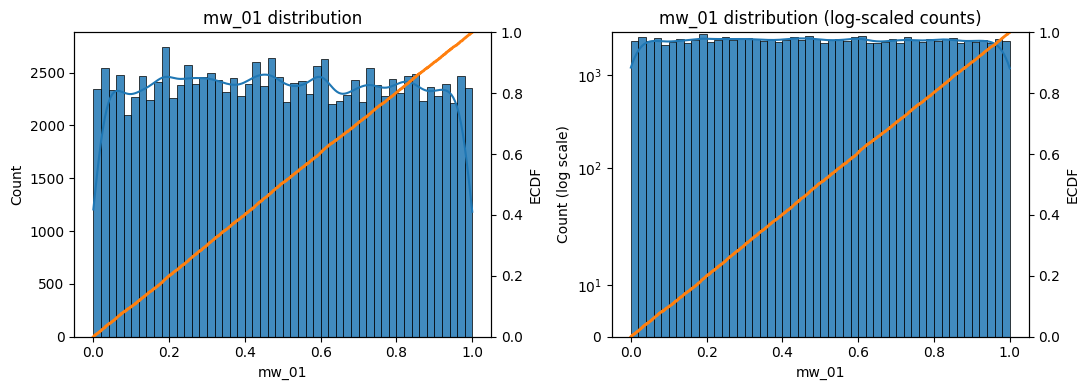

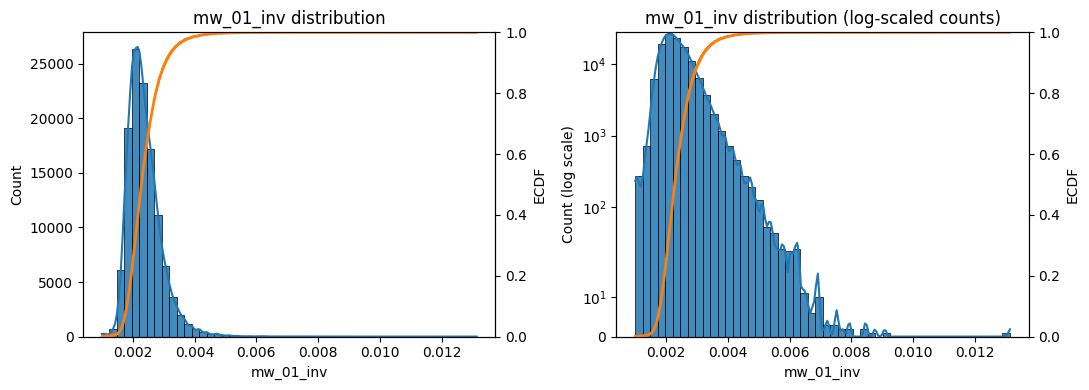

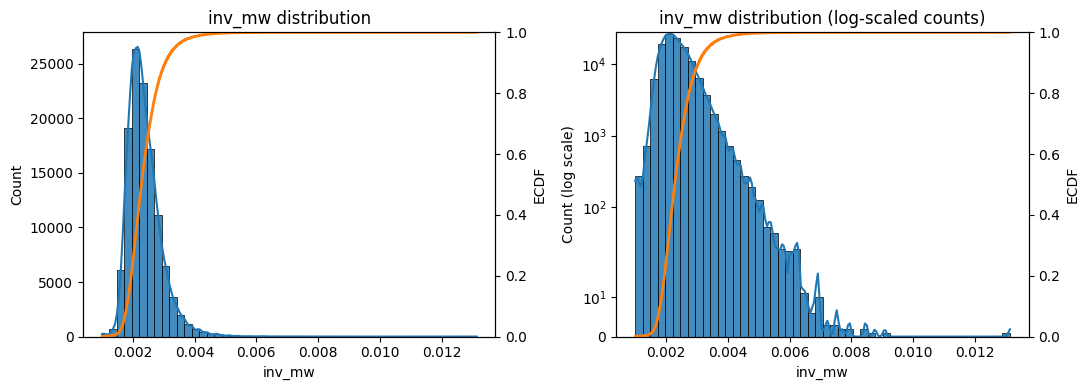

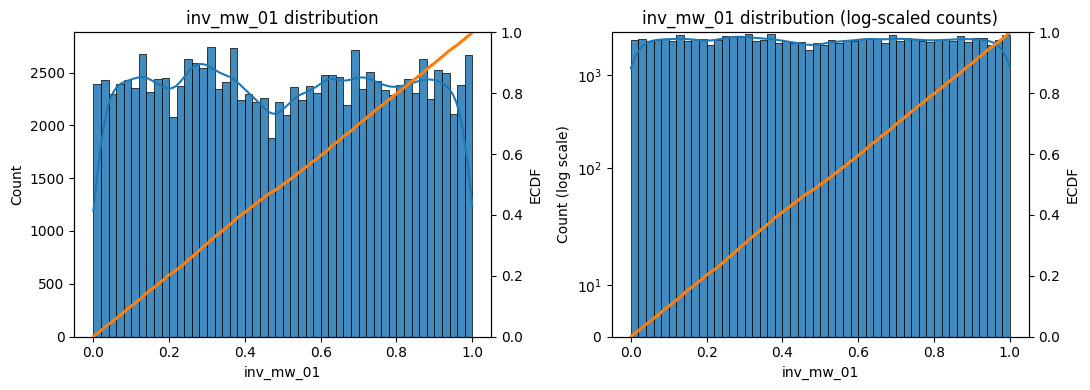

In [66]:
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer


def exp_transform_mw(mapping: pd.DataFrame, in_col: str, out_col: str, eps: float = 1e-3,
):
    MW_MIN = mapping[in_col].quantile(0.01) 
    lam = 1 / 100  # tune this

    mw_eff = mapping[in_col].clip(lower=MW_MIN)
    mapping[out_col] = 1 - np.exp(-lam * (mw_eff - MW_MIN))

    mapping[out_col] = eps + (1 - eps) * mapping[out_col]
    return mapping

transform = QuantileTransformer(
    output_distribution="uniform",
    n_quantiles=10000,
)
# mapping["mw_01"] = qt.fit_transform(mapping[["mw"]])


# First scale MWs to [0.1, 100], then take inverse
# transform = MinMaxScaler(feature_range=(0.01, 100))


mapping["mw_01"] = transform.fit_transform(mapping[["mw_filtered"]])

plot_dist_with_log(mapping, "mw_01", bins=50, kde=True, show_ecdf=True)

mapping["mw_01_inv"] = 1 / mapping["mw_filtered"]

plot_dist_with_log(mapping, "mw_01_inv", bins=50, kde=True, show_ecdf=True)


# First take inverse of MWs, then scale to [0.1, 100]
mapping["inv_mw"] = 1 / mapping["mw_filtered"]

plot_dist_with_log(mapping, "inv_mw", bins=50, kde=True, show_ecdf=True)

mapping["inv_mw_01"] = transform.fit_transform(mapping[["inv_mw"]])


print("Scale first then inverse", mapping["mw_01_inv"].describe())
print()
print("Inverse first then scale", mapping["inv_mw_01"].describe())

# plot_dist(mapping, "mw_01_inv")
# plot_dist_log(mapping, "mw_01_inv")
plot_dist_with_log(mapping, "inv_mw_01", bins=50, kde=True, show_ecdf=True)

To get the total number of h-bonds

In [22]:
hydrogen_bonds_df.columns

Index(['RESNR', 'RESTYPE', 'RESCHAIN', 'RESNR_LIG', 'RESTYPE_LIG',
       'RESCHAIN_LIG', 'SIDECHAIN', 'DIST_H-A', 'DIST_D-A', 'DON_ANGLE',
       'PROTISDON', 'DONORIDX', 'DONORTYPE', 'ACCEPTORIDX', 'ACCEPTORTYPE',
       'LIGCOO', 'PROTCOO', 'activity_id', 'bond_score'],
      dtype='object')

### Trying normalized weights

In [60]:
weights = (mapping.set_index("activity_id")["inv_mw_01"]).rename("mw_weight")
print(len(weights))
weights.describe()

119522


count    119522.000000
mean          0.498099
std           0.290779
min           0.000000
25%           0.245621
50%           0.496100
75%           0.750875
max           1.000000
Name: mw_weight, dtype: float64

113453

The number of bonds per complex

119522
count    112559.000000
mean          1.359959
std           1.012656
min           0.000000
25%           0.573330
50%           1.145755
75%           1.918619
max           8.106211
Name: weighted_num_hbs, dtype: float64


,activity_id,num_h_bonds,mw_weight,weighted_num_hbs,ident,y_processed
0,32335,1.0,0.781828,0.781828,0,5.148742
1,40693,NaN,0.719139,NaN,17,6.000000
2,41979,2.0,0.929118,1.858236,20,5.565431
3,51886,2.0,0.655216,1.310431,44,6.568636
4,443639,1.0,0.820682,0.820682,1221,5.640165


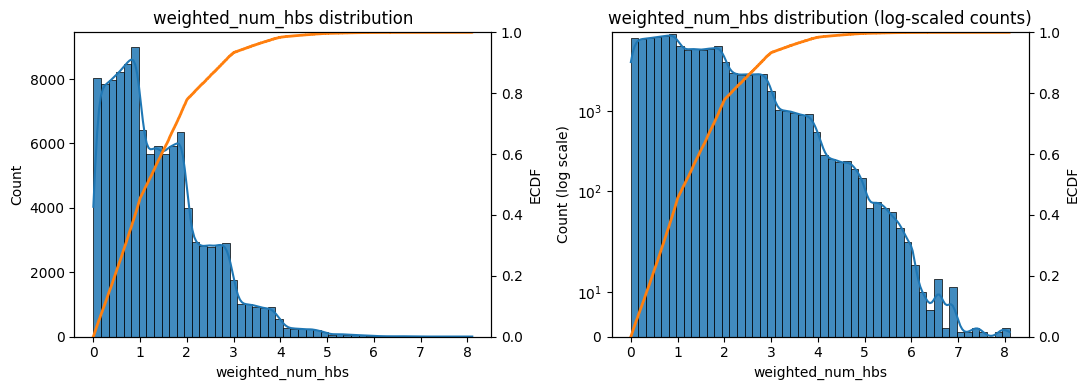

In [58]:
num_hydrogen_bonds = hydrogen_bonds_df['activity_id'].value_counts().reset_index(name='num_h_bonds')
num_hydrogen_bonds = num_hydrogen_bonds.merge(weights, on='activity_id', how='right')
num_hydrogen_bonds['weighted_num_hbs'] = (num_hydrogen_bonds['num_h_bonds'] * num_hydrogen_bonds['mw_weight'])
num_hydrogen_bonds = num_hydrogen_bonds.merge(mapping[['activity_id', 'ident', 'y_processed']], on='activity_id', how='left')

print(len(num_hydrogen_bonds))

plot_dist_with_log(num_hydrogen_bonds, "weighted_num_hbs", bins=50, kde=True, show_ecdf=True)
print(num_hydrogen_bonds["weighted_num_hbs"].describe())

num_hydrogen_bonds.head()

The summed score per complex

119522
count    112559.000000
mean          0.336768
std           0.255963
min           0.000000
25%           0.133848
50%           0.281679
75%           0.491587
max           1.823936
Name: weighted_hb_score, dtype: float64


,activity_id,sum_hb_score,mw_weight,weighted_hb_score,ident,y_processed
0,32335,0.150,0.781828,0.117274,0,5.148742
1,40693,NaN,0.719139,NaN,17,6.000000
2,41979,0.622,0.929118,0.577911,20,5.565431
3,51886,0.549,0.655216,0.359713,44,6.568636
4,443639,0.065,0.820682,0.053344,1221,5.640165


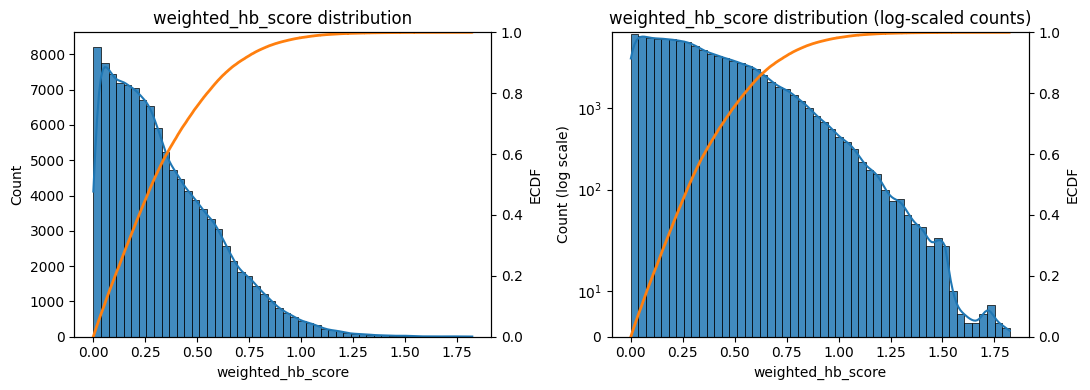

In [ ]:
# bond_score_col = "bond_score_gauss"
bond_score_col = "bond_score"

bond_scores = (
    hydrogen_bonds_df
    .groupby("activity_id", as_index=False)[bond_score_col]
    .sum()
    .rename(columns={bond_score_col: "sum_hb_score"})
)
bond_scores = bond_scores.merge(weights, on='activity_id', how='right')
bond_scores['weighted_hb_score'] = (bond_scores['sum_hb_score'] * bond_scores['mw_weight'])
bond_scores = bond_scores.merge(mapping[['activity_id', 'ident', 'y_processed']], on='activity_id', how='left')

print(len(bond_scores))

plot_dist_with_log(bond_scores, "weighted_hb_score", bins=50, kde=True, show_ecdf=True)
print(bond_scores["weighted_hb_score"].describe())

bond_scores.head()

Filter Outliers

In [51]:
interactions = {
    "weighted_hb_score": bond_scores,
    "weighted_num_hbs": num_hydrogen_bonds
}

In [ ]:
from prob.paths_and_io import save_out_tensor


for intr_name, intr_df in interactions.items():
    # store it as a dict of ident:value
    interaction_dict = intr_df.set_index('ident')[intr_name].to_dict()
    save_out_tensor(interaction_dict, output_dir = _ROOT/"data/probing/targets", filename = f"{intr_name}.pt")

## Calculate Correlations

In [52]:
def compute_correlations(
    df: pd.DataFrame,
    bond_col: str,
    y_col: str = "y_processed",
) -> dict[str, float]:
    """Compute Pearson and Spearman correlations between number of bonds and affinity."""
    sub_df = df[[bond_col, y_col]].dropna()
    pearson = sub_df.corr(method="pearson").iloc[0, 1]
    spearman = sub_df.corr(method="spearman").iloc[0, 1]
    return {"pearson": pearson, "spearman": spearman}


def compute_bond_stats(
    df: pd.DataFrame,
    bond_col: str,
) -> dict[str, float]:
    """Compute basic statistics (mean, median, variance) for bond counts."""
    sub_series = df[bond_col].dropna()
    return {
        "mean": round(sub_series.mean(), 3),
        "median": round(sub_series.median(), 3),
        "variance": round(sub_series.var(), 3),
    }


def plot_scatter_with_regression(
    df: pd.DataFrame, bond_col: str, y_col: str = "y_processed",
    hue: str = None,
    dropna: bool = True,
    title: str = None,):
    """ Scatter plot with regression line. """
    data = df[[bond_col, y_col] + ([hue] if hue else [])]
    
    if dropna:
        data = data.dropna()

    plt.figure(figsize=(6, 5))
    sns.regplot(
        data=data,
        x=bond_col,
        y=y_col,
        scatter_kws={"alpha": 0.2, "s": 10},
        line_kws={"color": "red"},
    )

    if title:
        plt.title(title)
    else:
        plt.title(f"{y_col} vs {bond_col}")

    plt.tight_layout()
    plt.show()

In [53]:
from scipy.stats import linregress

def plot_scatter_with_regression(
    df: pd.DataFrame,
    bond_col: str,
    y_col: str = "y_processed",
    dropna: bool = True,
    title: str = None,
    subsample: int | None = 5000,
    use_hexbin: bool = True,
):
    data = df[[bond_col, y_col]]
    if dropna:
        data = data.dropna()

    # --- regression on FULL data ---
    res = linregress(data[bond_col], data[y_col])

    print(
        f"[Linear regression]\n"
        # f"slope     = {res.slope:.4f}\n"
        # f"intercept = {res.intercept:.4f}\n"
        # f"r         = {res.rvalue:.4f}\n"
        f"r^2       = {res.rvalue**2:.4f}\n"
        f"p-value   = {res.pvalue:.2e}\n"
    )

    # --- subsample for visualization ---
    if subsample is not None and len(data) > subsample:
        data_vis = data.sample(subsample, random_state=0)
    else:
        data_vis = data

    plt.figure(figsize=(6, 5))

    if use_hexbin:
        plt.hexbin(
            data_vis[bond_col],
            data_vis[y_col],
            gridsize=40,
            cmap="viridis",
        )
        plt.colorbar(label="count")

        # regression line
        x = np.linspace(data[bond_col].min(), data[bond_col].max(), 100)
        y = res.intercept + res.slope * x
        plt.plot(x, y, color="red", linewidth=2)

    else:
        sns.regplot(
            data=data_vis,
            x=bond_col,
            y=y_col,
            scatter_kws={"alpha": 0.3, "s": 20},
            line_kws={"color": "red"},
        )

    plt.xlabel(bond_col)
    plt.ylabel(y_col)

    if title:
        plt.title(title)
    else:
        plt.title(f"{y_col} vs {bond_col}")

    plt.tight_layout()
    plt.show()

In [36]:
bond_scores.head()

,activity_id,sum_hb_score,mw_weight,weighted_hb_score,ident,y_processed
0,32335,0.709,14.010835,9.933682,0,5.148742
1,40693,NaN,13.090127,NaN,17,6.000000
2,41979,1.843,18.063027,33.290158,20,5.565431
3,51886,1.451,12.242623,17.764045,44,6.568636
4,443639,0.398,14.756055,5.872910,1221,5.640165



weighted_hb_score correlations: {'pearson': -0.10313653083659223, 'spearman': -0.12155280632838181}
stats: {'mean': 2.242, 'median': 1.45, 'variance': 6.673}
[Linear regression]
r^2       = 0.0106
p-value   = 9.61e-264



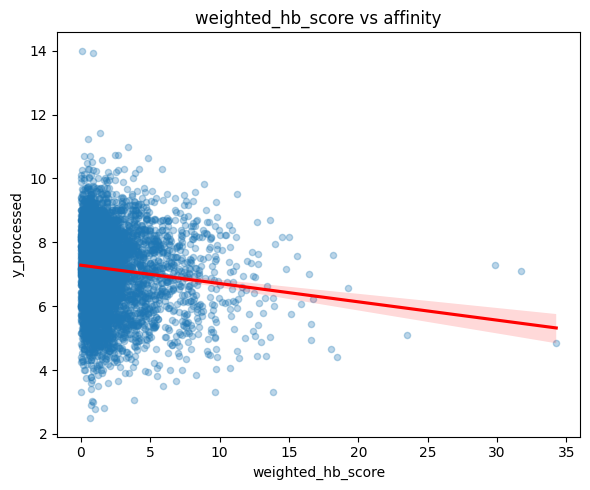


weighted_num_hbs correlations: {'pearson': -0.13143623096175489, 'spearman': -0.13994104679686142}
stats: {'mean': 1.36, 'median': 1.146, 'variance': 1.025}
[Linear regression]
r^2       = 0.0173
p-value   = 0.00e+00



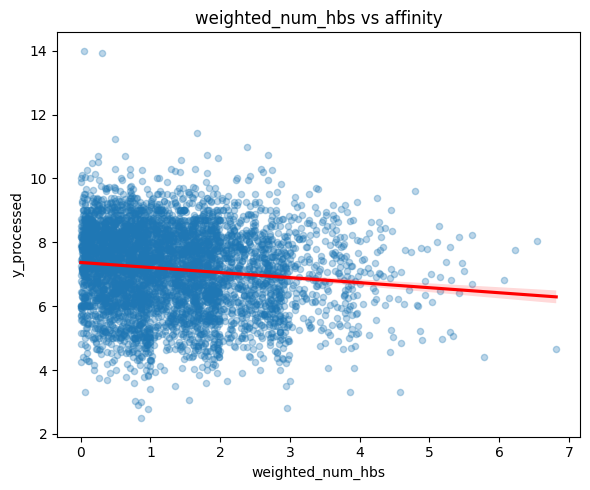

In [59]:
for intr_name, intr_df in interactions.items():
    corrs = compute_correlations(intr_df, bond_col=intr_name)
    print(f"\n{intr_name} correlations: {corrs}")
    print(f"stats: {compute_bond_stats(intr_df, bond_col=intr_name)}")
    plot_scatter_with_regression(
        intr_df,
        bond_col=intr_name,
        title=f"{intr_name} vs affinity",
        use_hexbin=False,
    )